In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [37]:

# --- 1. carregar o dataset ---
ARQUIVO_ENTRADA = 'arquivos\dataset_artigo.csv'

try:
    df = pd.read_csv(ARQUIVO_ENTRADA)
    print(f"Dataset '{ARQUIVO_ENTRADA}' carregado com sucesso, contendo {len(df)} linhas.")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{ARQUIVO_ENTRADA}' não foi encontrado.")
    df = None


Dataset 'arquivos\dataset_artigo.csv' carregado com sucesso, contendo 421 linhas.


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\john.araujo\AppData\Local\Temp\ipykernel_2500\4113963781.py:2: SyntaxWarning: invalid escape sequence '\d'
  ARQUIVO_ENTRADA = 'arquivos\dataset_artigo.csv'


Dados preparados para a análise.

Calculando a inércia para cada valor de k...
  k=1, Inércia=842.00
  k=2, Inércia=517.28
  k=3, Inércia=343.54
  k=4, Inércia=225.35
  k=5, Inércia=159.09
  k=6, Inércia=121.23
  k=7, Inércia=100.26
  k=8, Inércia=75.34
  k=9, Inércia=64.11
  k=10, Inércia=58.23

--- Gerando o Gráfico do Método do Cotovelo (Elbow Method) ---


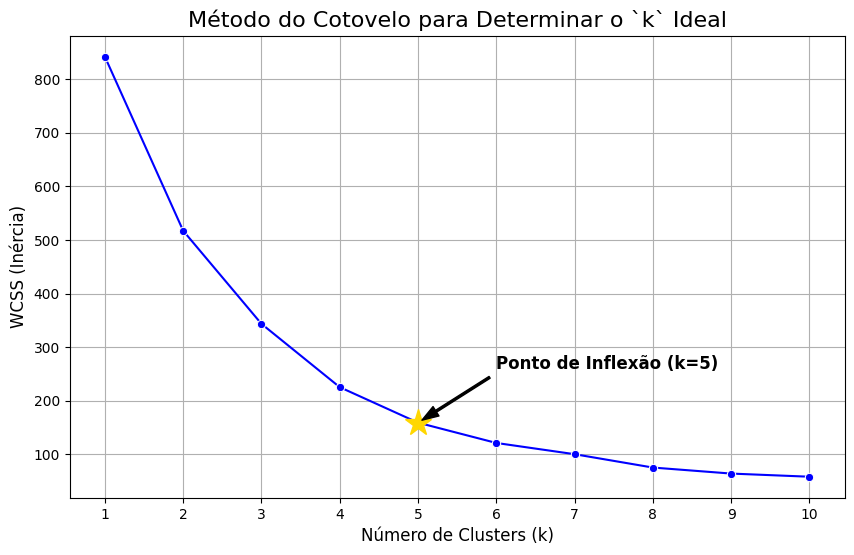


Interpretação: O 'cotovelo' no gráfico é o ponto onde a taxa de diminuição da inércia se torna menos acentuada. Este gráfico destaca k=5 como o ponto de equilíbrio onde adicionar mais clusters não traz um benefício tão significativo.


In [38]:
if df is not None:
    # --- 2. preparar os dados para clusterização ---
    features = ['epss', 'ppsi_normalizado']
    X = df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("Dados preparados para a análise.")

    # --- 3. executando o k-means para uma faixa de 'k' ---
    wcss = [] # within-cluster sum of squares (inércia)
    k_range = range(1, 11) # testar de 1 a 10 clusters

    print("\nCalculando a inércia para cada valor de k...")
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
        print(f"  k={k}, Inércia={kmeans.inertia_:.2f}")

    # --- 4. gerando o gráfico do método do cotovelo ---
    print("\n--- Gerando o Gráfico do Método do Cotovelo (Elbow Method) ---")
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=k_range, y=wcss, marker='o', color='b')
    plt.title('Método do Cotovelo para Determinar o `k` Ideal', fontsize=16)
    plt.xlabel('Número de Clusters (k)', fontsize=12)
    plt.ylabel('WCSS (Inércia)', fontsize=12)
    plt.xticks(k_range)
    plt.grid(True)

    # --- destaque para o ponto de inflexão em k=5 ---
    k_destaque = 5
    # garante que o índice para wcss está correto (k_range começa em 1, lista em 0)
    indice_wcss = k_destaque - 1

    plt.annotate(f'Ponto de Inflexão (k={k_destaque})',
                 xy=(k_destaque, wcss[indice_wcss]),
                 xytext=(k_destaque + 1, wcss[indice_wcss] + 100),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                 fontsize=12,
                 fontweight='bold')
    # adiciona um marcador especial no ponto
    plt.plot(k_destaque, wcss[indice_wcss], marker='*', color='gold', markersize=20)


    plt.show()
    print("\nInterpretação: O 'cotovelo' no gráfico é o ponto onde a taxa de diminuição da inércia se torna menos acentuada. Este gráfico destaca k=5 como o ponto de equilíbrio onde adicionar mais clusters não traz um benefício tão significativo.")

Dataset 'arquivos\dataset_artigo.csv' carregado com sucesso.
Dados preparados para a clusterização.

--- Gerando o Dendrograma para análise exploratória ---


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\john.araujo\AppData\Local\Temp\ipykernel_2500\1391330852.py:9: SyntaxWarning: invalid escape sequence '\d'
  ARQUIVO_ENTRADA = 'arquivos\dataset_artigo.csv'


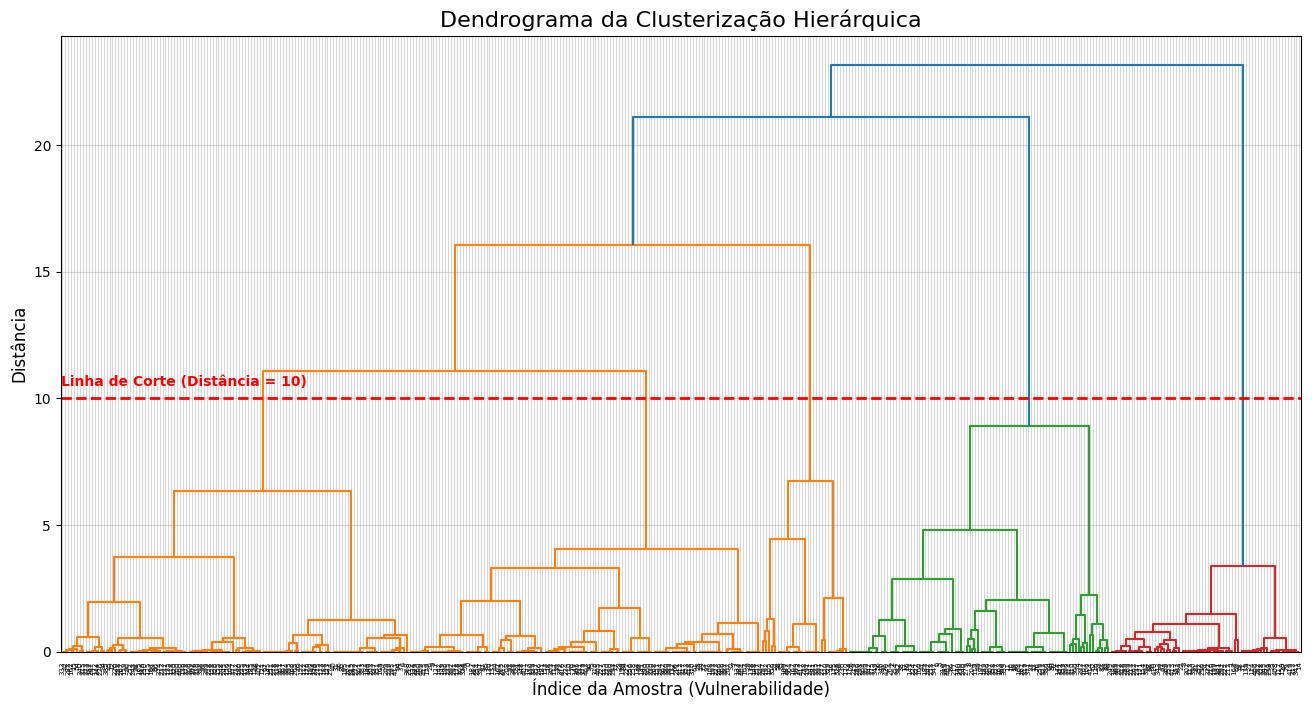


Clusterização Hierárquica executada com sucesso para k=5.

--- Análise das Médias e Re-rotulação dos Clusters Hierárquicos ---
Clusters re-rotulados de 'Crítico' a 'Mínimo'.
                        epss  ppsi_normalizado
perfil_de_risco_hc                            
Crítico             0.319451          0.855203
Alto                0.645581          0.362797
Médio               0.322790          0.400550
Baixo               0.076459          0.434152
Mínimo              0.018288          0.071158

--- Visualização Gráfica dos Clusters Hierárquicos ---


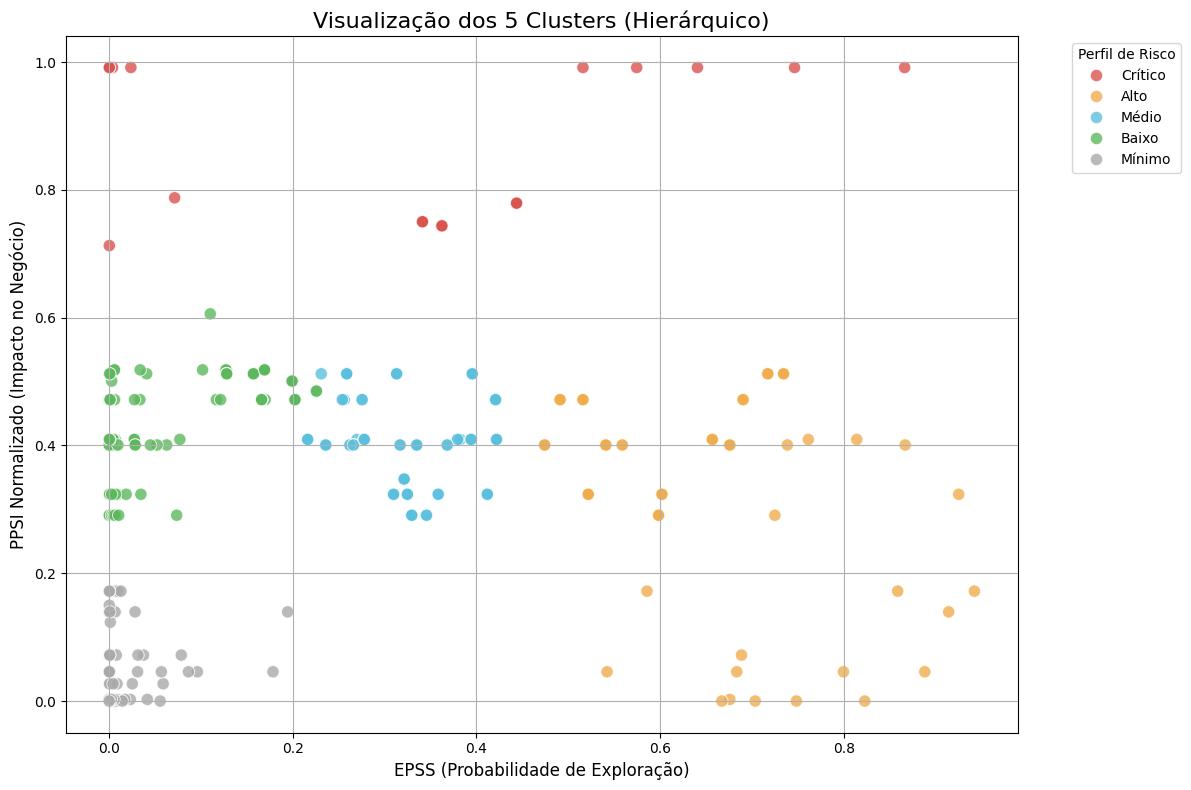

In [39]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# --- 1. carregar e preparar o dataset ---
ARQUIVO_ENTRADA = 'arquivos\dataset_artigo.csv'
try:
    df = pd.read_csv(ARQUIVO_ENTRADA)
    print(f"Dataset '{ARQUIVO_ENTRADA}' carregado com sucesso.")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{ARQUIVO_ENTRADA}' não foi encontrado.")
    df = None

if df is not None:
    features = ['epss', 'ppsi_normalizado']
    X = df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("Dados preparados para a clusterização.")

    # --- 2. análise exploratória: geração do dendrograma ---
    print("\n--- Gerando o Dendrograma para análise exploratória ---")

    linked = linkage(X_scaled, method='ward')

    plt.figure(figsize=(16, 8))
    # capturamos o eixo (ax) para poder desenhar nele
    ax = plt.gca()

    dendrogram(linked,
               orientation='top',
               distance_sort='descending',
               show_leaf_counts=True,
               ax=ax)

    # --- ajuste realizado aqui ---
    # adicionando a linha de corte vermelha e "em negrito" (mais espessa)
    altura_de_corte = 10
    ax.axhline(y=altura_de_corte, color='r', linestyle='--', linewidth=2)
    ax.text(x=0, y=altura_de_corte + 0.5, s=f'Linha de Corte (Distância = {altura_de_corte})', color='red', fontweight='bold')
    # -------------------------

    plt.title('Dendrograma da Clusterização Hierárquica', fontsize=16)
    plt.xlabel('Índice da Amostra (Vulnerabilidade)', fontsize=12)
    plt.ylabel('Distância', fontsize=12)
    plt.grid(True, which='both', axis='both', linestyle='-', alpha=0.5) 
    plt.show()

   
    # --- 3. aplicar a clusterização hierárquica com k=5 ---
    k = 5
    hierarchical_cluster = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    df['hc_cluster_raw'] = hierarchical_cluster.fit_predict(X_scaled)
    print(f"\nClusterização Hierárquica executada com sucesso para k={k}.")

    # --- 4. análise dos clusters gerados e re-rotulação ---
    print("\n--- Análise das Médias e Re-rotulação dos Clusters Hierárquicos ---")

    analise_hc = df.groupby('hc_cluster_raw')[features].mean()
    # cria um score de risco para ordenar os clusters
    analise_hc['risk_score'] = analise_hc['epss'] + analise_hc['ppsi_normalizado']
    centroides_ordenados = analise_hc.sort_values(by='risk_score', ascending=False)

    # define os nomes para os 5 perfis de risco
    nomes_perfis = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']
    mapa_rotulos = {indice: nome for indice, nome in zip(centroides_ordenados.index, nomes_perfis)}

    # cria a nova coluna com os nomes dos perfis
    df['perfil_de_risco_hc'] = df['hc_cluster_raw'].map(mapa_rotulos)
    print("Clusters re-rotulados de 'Crítico' a 'Mínimo'.")

    # exibe a tabela de resultados com os novos nomes
    tabela_final = df.groupby('perfil_de_risco_hc')[features].mean().reindex(nomes_perfis)
    print(tabela_final)

    # --- 5. visualização gráfica dos clusters hierárquicos com paleta correta ---
    print("\n--- Visualização Gráfica dos Clusters Hierárquicos ---")
    plt.figure(figsize=(12, 8))


    # paleta de cores personalizada
    paleta_cores = {
        'Crítico': '#d9534f',
        'Alto': '#f0ad4e',
        'Médio': '#5bc0de',
        'Baixo': '#5cb85c',
        'Mínimo': '#a9a9a9'
    }

    sns.scatterplot(
        data=df,
        x='epss',
        y='ppsi_normalizado',
        hue='perfil_de_risco_hc', # usa a nova coluna com os nomes
        hue_order=nomes_perfis,   # garante a ordem correta na legenda
        palette=paleta_cores,     # aplica a paleta personalizada
        s=80,
        alpha=0.8
    )

    plt.title(f'Visualização dos {k} Clusters (Hierárquico)', fontsize=16)
    plt.xlabel('EPSS (Probabilidade de Exploração)', fontsize=12)
    plt.ylabel('PPSI Normalizado (Impacto no Negócio)', fontsize=12)
    plt.legend(title='Perfil de Risco', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [40]:

if df is not None:
    # --- 2. preparar os dados para clusterização ---
    # selecionamos as features que definem o risco
    features = ['epss', 'ppsi_normalizado']

    if not all(col in df.columns for col in features):
        print(f"ERRO: O dataset não contém as colunas necessárias: {features}")
    else:
        X = df[features]

        # padronizar os dados é crucial para o k-means
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        print("\nFeatures selecionadas e normalizadas para a análise.")

        # --- 3. aplicar o algoritmo k-means ---
        k = 5
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)

        # atribui um cluster inicial (arbitrário) a cada vulnerabilidade
        df['cluster_raw'] = kmeans.fit_predict(X_scaled)
        print(f"k-Means executado com sucesso para k={k}.")

        # --- 4. análise dos centroides e re-rotulação ordenada ---
        print("\n--- Analisando e ordenando os clusters por nível de risco ---")

        # calcula os centroides
        analise_centroides = df.groupby('cluster_raw')[features].mean()

        # cria um score de risco para ordenar os clusters (ex: baseado na soma de epss e ppsi)
        analise_centroides['risk_score'] = analise_centroides['epss'] + analise_centroides['ppsi_normalizado']

        # ordena os clusters do maior risco para o menor
        centroides_ordenados = analise_centroides.sort_values(by='risk_score', ascending=False)

        # cria o mapa de re-rotulação (ex: cluster 3 -> 0 - crítico, cluster 1 -> 1 - alto, etc.)
        nomes_perfis = ['0 - Crítico', '1 - Alto', '2 - Médio', '3 - Baixo', '4 - Mínimo']
        mapa_rotulos = {indice: nome for indice, nome in zip(centroides_ordenados.index, nomes_perfis)}

        # aplica o novo rótulo ordenado ao dataframe
        df['perfil_de_risco'] = df['cluster_raw'].map(mapa_rotulos)
        print("Clusters re-rotulados de 'Crítico' a 'Mínimo'.")

        # --- 5. apresentação dos resultados ---
        print("\n--- Tabela Final de Análise dos Centroides (Perfis de Risco) ---")

        # exibe a análise final, agora com os perfis ordenados e nomeados
        analise_final = df.groupby('perfil_de_risco')[features].mean().sort_index()
        print(analise_final)




Features selecionadas e normalizadas para a análise.
k-Means executado com sucesso para k=5.

--- Analisando e ordenando os clusters por nível de risco ---
Clusters re-rotulados de 'Crítico' a 'Mínimo'.

--- Tabela Final de Análise dos Centroides (Perfis de Risco) ---
                     epss  ppsi_normalizado
perfil_de_risco                            
0 - Crítico      0.330841          0.860288
1 - Alto         0.670722          0.346964
2 - Médio        0.338284          0.407081
3 - Baixo        0.073256          0.435662
4 - Mínimo       0.018288          0.071158


Dados preparados para a clusterização.
k-Means executado e 5 perfis de risco foram definidos.

--- Heatmap dos Perfis de Risco ---


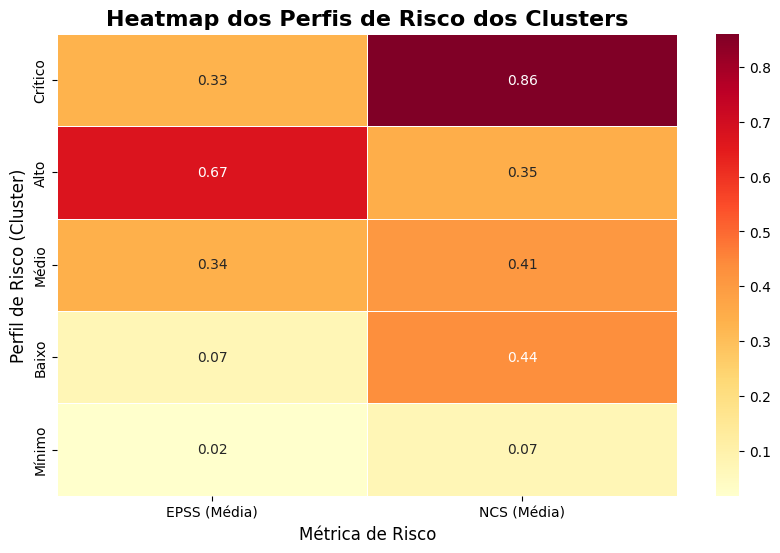

In [41]:
if df is not None:
    features = ['epss', 'ppsi_normalizado']
    X = df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("Dados preparados para a clusterização.")

    # --- 2. executar k-means e re-rotular os clusters ---
    k = 5
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    df['cluster_raw'] = kmeans.fit_predict(X_scaled)

    # re-rotulando os clusters por nível de risco para criar os perfis
    centroides_analise = df.groupby('cluster_raw')[features].mean()
    centroides_analise['risk_score'] = centroides_analise['epss'] + centroides_analise['ppsi_normalizado']
    centroides_ordenados = centroides_analise.sort_values(by='risk_score', ascending=False)

    nomes_perfis = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']
    mapa_rotulos = {indice: nome for indice, nome in zip(centroides_ordenados.index, nomes_perfis)}
    df['perfil_de_risco'] = df['cluster_raw'].map(mapa_rotulos)
    print(f"k-Means executado e {k} perfis de risco foram definidos.")

    # gera a análise final agrupando pelos perfis nomeados
    tabela_centroides = df.groupby('perfil_de_risco')[features].mean().reindex(nomes_perfis)

    # ajusta a tabela para o formato solicitado
    tabela_final = tabela_centroides.rename(columns={
        'epss': 'EPSS (Média)',
        'ppsi_normalizado': 'NCS (Média)'
    }).reset_index().rename(columns={'perfil_de_risco': 'Perfil de Risco Proposto'})

    # adiciona a coluna cluster id
    tabela_final['Cluster ID'] = tabela_final.index

    # reordena para o formato final
    tabela_final = tabela_final[['Cluster ID', 'EPSS (Média)', 'NCS (Média)', 'Perfil de Risco Proposto']]


    # --- 4. gerando o heatmap (mapa de calor) ---
    print("\n--- Heatmap dos Perfis de Risco ---")

    # prepara os dados para o heatmap (usando o perfil como índice)
    heatmap_data = tabela_final.set_index('Perfil de Risco Proposto')[['EPSS (Média)', 'NCS (Média)']]

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,        # mostra os valores numéricos
        cmap='YlOrRd',     # paleta de cores do amarelo ao vermelho para indicar risco
        fmt=".2f",         # formato dos números
        linewidths=.5
    )
    plt.title('Heatmap dos Perfis de Risco dos Clusters', fontsize=16, weight='bold')
    plt.xlabel('Métrica de Risco', fontsize=12)
    plt.ylabel('Perfil de Risco (Cluster)', fontsize=12)
    plt.show()


--- Visualização Gráfica dos Perfis de Risco ---


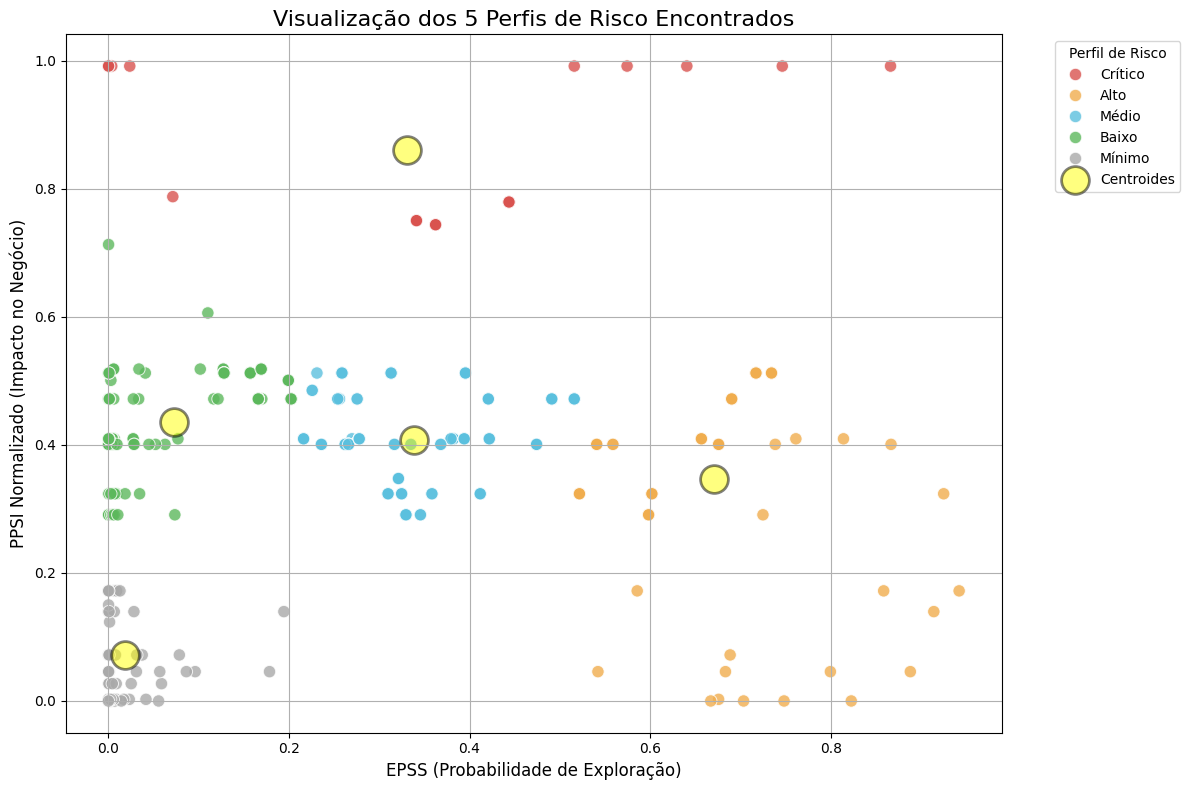

In [42]:
if df is not None:
    # --- 2. preparar os dados para clusterização ---
    features = ['epss', 'ppsi_normalizado']

    if not all(col in df.columns for col in features):
        print(f"ERRO: O dataset não contém as colunas necessárias: {features}")
    else:
        X = df[features]
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # --- 3. aplicar o algoritmo k-means ---
        k = 5
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
        df['cluster_raw'] = kmeans.fit_predict(X_scaled)

        nomes_perfis = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']
        mapa_rotulos = {indice: nome for indice, nome in zip(centroides_ordenados.index, nomes_perfis)}

        df['perfil_de_risco'] = df['cluster_raw'].map(mapa_rotulos)


        print("\n--- Visualização Gráfica dos Perfis de Risco ---")
        plt.figure(figsize=(12, 8))

        paleta_cores = {
            'Crítico': '#d9534f',
            'Alto': '#f0ad4e',
            'Médio': '#5bc0de',
            'Baixo': '#5cb85c',
            'Mínimo': '#a9a9a9'
        }

        # plota a dispersão das vulnerabilidades
        sns.scatterplot(
            data=df,
            x='epss',
            y='ppsi_normalizado',
            hue='perfil_de_risco',
            hue_order=nomes_perfis,
            palette=paleta_cores,
            s=80,
            alpha=0.8
        )

        # destacando os centroides com círculos amarelos semi-transparentes
        centroides_reais = scaler.inverse_transform(kmeans.cluster_centers_)
        plt.scatter(
            centroides_reais[:, 0],
            centroides_reais[:, 1],
            s=400,                  # tamanho grande
            c='yellow',             # cor amarela
            marker='o',             # marcador de círculo
            label='Centroides',
            alpha=0.5,              # 50% de transparência
            edgecolor='black',      # borda preta para destaque
            linewidth=2
        )

        plt.title(f'Visualização dos {k} Perfis de Risco Encontrados', fontsize=16)
        plt.xlabel('EPSS (Probabilidade de Exploração)', fontsize=12)
        plt.ylabel('PPSI Normalizado (Impacto no Negócio)', fontsize=12)
        plt.legend(title='Perfil de Risco', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Dados preparados para a clusterização.
Algoritmos k-Means e DBSCAN executados.

--- Gerando a imagem comparativa final ---


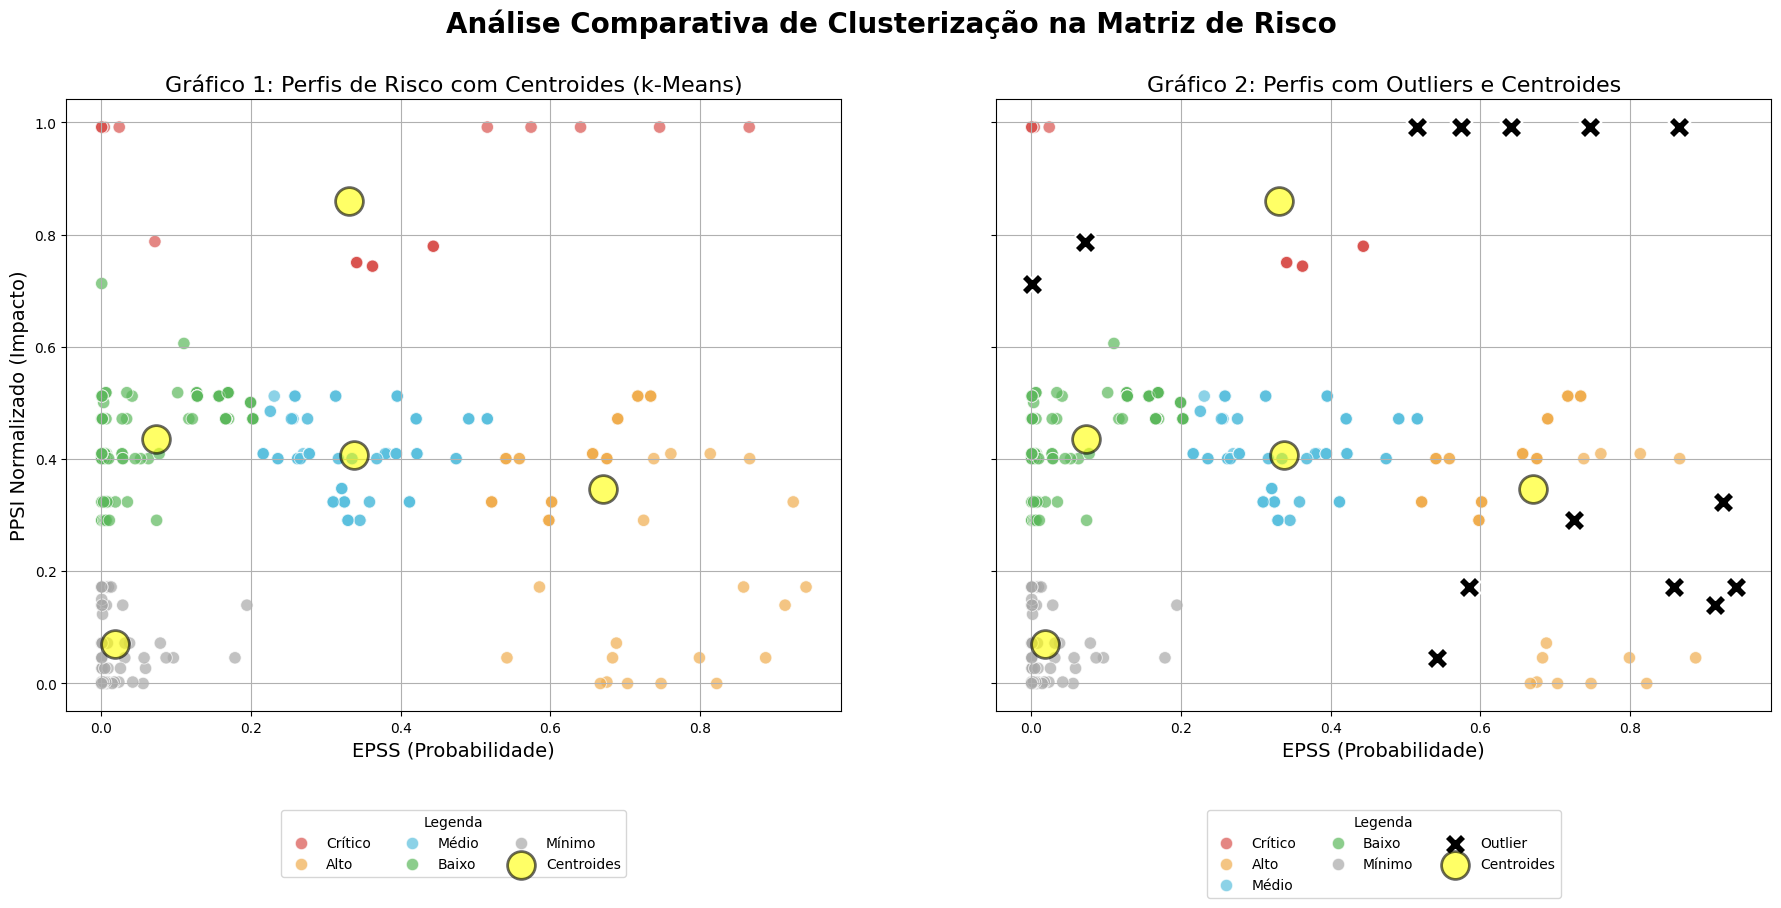

In [43]:
if df is not None:
    features = ['epss', 'ppsi_normalizado']
    X = df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("Dados preparados para a clusterização.")

    # --- 2. executar os dois algoritmos ---
    k = 5
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    df['kmeans_cluster_raw'] = kmeans.fit_predict(X_scaled)

    # re-rotulando os clusters do k-means por nível de risco
    centroides_analise = df.groupby('kmeans_cluster_raw')[features].mean()
    centroides_analise['risk_score'] = centroides_analise['epss'] + centroides_analise['ppsi_normalizado']
    centroides_ordenados = centroides_analise.sort_values(by='risk_score', ascending=False)
    nomes_perfis = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']
    mapa_rotulos = {indice: nome for indice, nome in zip(centroides_ordenados.index, nomes_perfis)}
    df['perfil_de_risco'] = df['kmeans_cluster_raw'].map(mapa_rotulos)

    # executando dbscan para identificar outliers
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    df['is_outlier'] = (dbscan.fit_predict(X_scaled) == -1)
    print("Algoritmos k-Means e DBSCAN executados.")

    # --- 3. gerando a imagem comparativa com estilo corrigido ---
    print("\n--- Gerando a imagem comparativa final ---")

    paleta_cores = {
        'Crítico': '#d9534f', 'alto': '#f0ad4e', 'médio': '#5bc0de',
        'Baixo': '#5cb85c', 'mínimo': '#a9a9a9'
    }
    ordem_hue = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']

    fig, axes = plt.subplots(1, 2, figsize=(22, 9), sharex=True, sharey=True)
    fig.suptitle('Análise Comparativa de Clusterização na Matriz de Risco', fontsize=20, weight='bold')

    centroides_reais = scaler.inverse_transform(kmeans.cluster_centers_)

    # --- gráfico 1: perfis de risco (k-means) ---
    ax1 = axes[0]
    sns.scatterplot(
        data=df, x='epss', y='ppsi_normalizado', hue='perfil_de_risco',
        hue_order=ordem_hue, palette=paleta_cores, s=80, alpha=0.7, ax=ax1
    )
    ax1.scatter(
        centroides_reais[:, 0], centroides_reais[:, 1],
        s=400, c='yellow', marker='o', label='Centroides',
        alpha=0.6, edgecolor='black', linewidth=2, zorder=3
    )
    ax1.set_title('Gráfico 1: Perfis de Risco com Centroides (k-Means)', fontsize=16)
    ax1.set_xlabel('EPSS (Probabilidade)', fontsize=14)
    ax1.set_ylabel('PPSI Normalizado (Impacto)', fontsize=14)
    ax1.legend(title='Legenda', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)
    ax1.grid(True)

    # --- gráfico 2: perfis de risco com outliers (k-means + dbscan) ---
    ax2 = axes[1]
    df_clusters = df[~df['is_outlier']]
    df_outliers = df[df['is_outlier']]

    # plota os pontos dos clusters, coloridos pelo perfil do k-means
    sns.scatterplot(
        data=df_clusters, x='epss', y='ppsi_normalizado', hue='perfil_de_risco',
        hue_order=ordem_hue, palette=paleta_cores, s=80, alpha=0.7, ax=ax2
    )

    # plota os outliers por cima com 'x' preto forte
    if not df_outliers.empty:
        ax2.scatter(
            df_outliers['epss'], df_outliers['ppsi_normalizado'],
            marker='X', color='black', s=250, label='Outlier',
            edgecolor='white', linewidth=1.5, zorder=4
        )

    # ajuste: adicionando os centroides também ao segundo gráfico para referência
    ax2.scatter(
        centroides_reais[:, 0], centroides_reais[:, 1],
        s=400, c='yellow', marker='o', label='Centroides',
        alpha=0.6, edgecolor='black', linewidth=2, zorder=3
    )

    ax2.set_title('Gráfico 2: Perfis com Outliers e Centroides', fontsize=16)
    ax2.set_xlabel('EPSS (Probabilidade)', fontsize=14)
    ax2.set_ylabel('')
    ax2.legend(title='Legenda', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)
    ax2.grid(True)

    plt.subplots_adjust(bottom=0.2)
    plt.show()

In [44]:
# --- 5. apresentação dos resultados ---
print("\n--- Tabela de Outliers Identificados (DBSCAN) ---")

if df is not None and 'is_outlier' in df.columns:
    df_outliers_final = df[df['is_outlier']]
    if not df_outliers_final.empty:
        colunas_outliers = ['cve', 'epss', 'ppsi_normalizado', 'cvss(qualitativo)', 'perfil_de_risco']
        colunas_exibir = [col for col in colunas_outliers if col in df_outliers_final.columns]
        print(f"Total de outliers encontrados: {len(df_outliers_final)}\n")
        from IPython.display import display
        display(df_outliers_final[colunas_exibir])
    else:
        print("Nenhum outlier foi identificado com os parâmetros atuais do DBSCAN.")
else:
    print("A coluna 'is_outlier' não foi encontrada. Execute a clusterização primeiro.")



--- Tabela de Outliers Identificados (DBSCAN) ---
Total de outliers encontrados: 14



,cve,epss,ppsi_normalizado,cvss(qualitativo),perfil_de_risco
49,CVE-2024-0195,0.92470,0.323600,CRITICAL,Alto
52,CVE-2003-0033,0.51588,0.991562,CRITICAL,Crítico
62,CVE-2003-0819,0.58556,0.171980,CRITICAL,Alto
86,CVE-2002-0148,0.72471,0.290785,CRITICAL,Alto
101,CVE-2000-0573,0.91378,0.139566,CRITICAL,Alto
105,CVE-2004-0397,0.86588,0.991562,CRITICAL,Crítico
106,CVE-2004-1037,0.85829,0.171980,CRITICAL,Alto
120,CVE-2023-0917,0.00053,0.712832,CRITICAL,Baixo
192,CVE-2002-2226,0.74610,0.991562,CRITICAL,Crítico
277,CVE-2001-0819,0.07161,0.787637,CRITICAL,Crítico



Executando k-Means para gerar os Perfis de Risco Propostos...
Coluna 'PRP' (Perfil de Risco Proposto) criada com sucesso.

Gerando o gráfico comparativo 'Antes vs. Depois'...


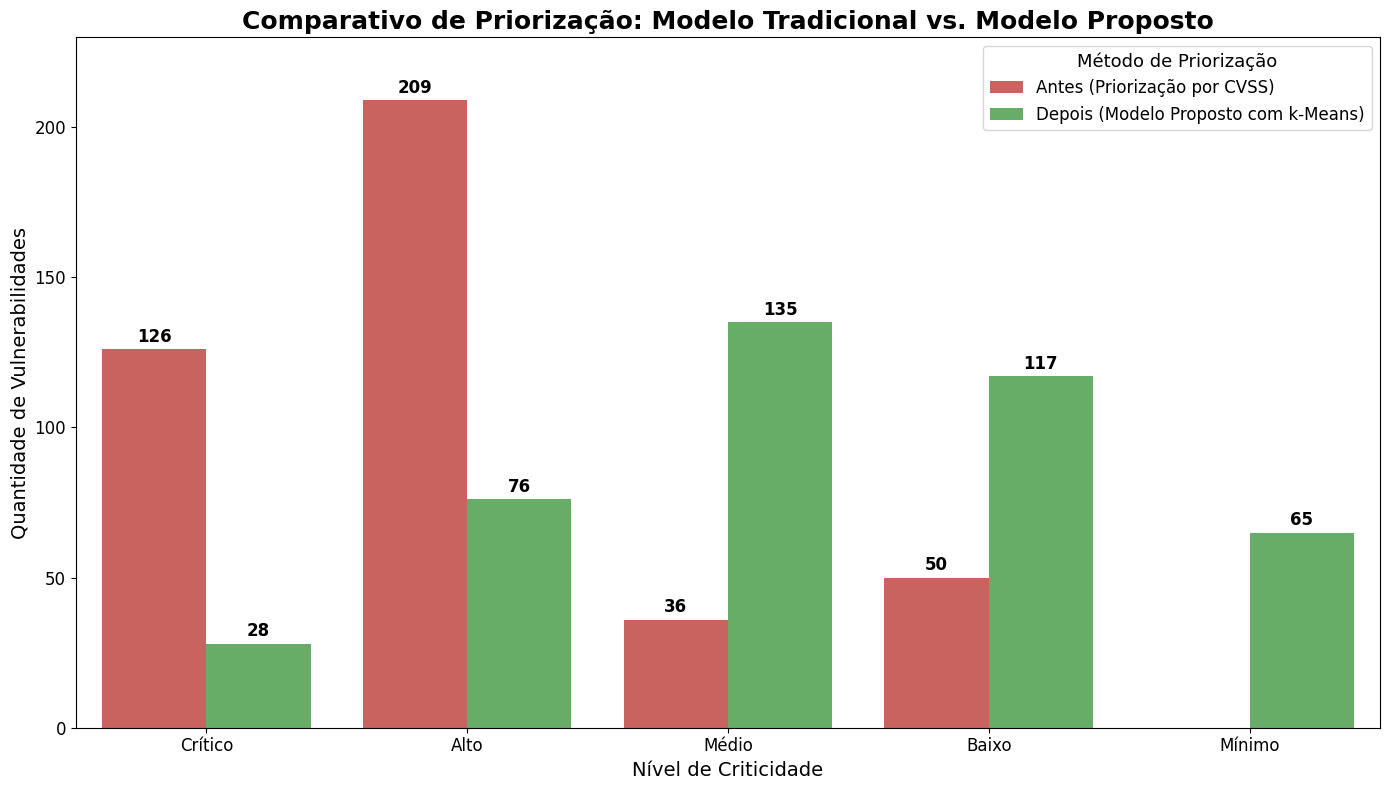

In [45]:
if df is not None:
    # --- 2. executar k-means para gerar a coluna prp (perfil de risco proposto) ---
    print("\nExecutando k-Means para gerar os Perfis de Risco Propostos...")
    features = ['epss', 'ppsi_normalizado']
    X = df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    k = 5
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    df['kmeans_cluster_raw'] = kmeans.fit_predict(X_scaled)

    # re-rotulando os clusters para nomes significativos
    centroides_analise = df.groupby('kmeans_cluster_raw')[features].mean()
    centroides_analise['risk_score'] = centroides_analise['epss'] + centroides_analise['ppsi_normalizado']
    centroides_ordenados = centroides_analise.sort_values(by='risk_score', ascending=False)
    nomes_perfis = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']
    mapa_rotulos = {indice: nome for indice, nome in zip(centroides_ordenados.index, nomes_perfis)}

    df['PRP'] = df['kmeans_cluster_raw'].map(mapa_rotulos)
    print("Coluna 'PRP' (Perfil de Risco Proposto) criada com sucesso.")

    # --- 3. preparar os dados para o gráfico comparativo ---

    # contagem do cenário "antes" a partir da coluna cvss
    # garantindo a padronização dos nomes (ex: 'critical' vira 'crítico')
    mapa_cvss = {'CRITICAL': 'Crítico', 'HIGH': 'Alto', 'MEDIUM': 'Médio', 'LOW': 'Baixo'}
    df['cvss_padronizado'] = df['cvss(qualitativo)'].str.upper().map(mapa_cvss)
    dados_antes = df['cvss_padronizado'].value_counts().reset_index()
    dados_antes.columns = ['Criticidade', 'Contagem']
    dados_antes['Método'] = 'Antes (Priorização por CVSS)'

    # contagem do cenário "depois" a partir da nova coluna prp
    dados_depois = df['PRP'].value_counts().reset_index()
    dados_depois.columns = ['Criticidade', 'Contagem']
    dados_depois['Método'] = 'Depois (Modelo Proposto com k-Means)'

    # combinar os dois dataframes em um só para a plotagem
    df_grafico = pd.concat([dados_antes, dados_depois])

    # --- 4. gerando o gráfico comparativo final lado a lado ---
    print("\nGerando o gráfico comparativo 'Antes vs. Depois'...")
    plt.figure(figsize=(14, 8))
    ordem_criticidade = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']

    ax = sns.barplot(
        data=df_grafico,
        x='Criticidade',
        y='Contagem',
        hue='Método', # o parâmetro 'hue' garante que as barras fiquem lado a lado
        order=ordem_criticidade,
        palette={'Antes (Priorização por CVSS)': '#d9534f', 'depois (modelo proposto com k-means)': '#5cb85c'}
    )

    # adiciona os valores no topo de cada barra
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(format(p.get_height(), '.0f'),
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha = 'center', va = 'center',
                           xytext = (0, 9),
                           textcoords = 'offset points',
                           fontsize=12, weight='bold')

    # configurações finais do gráfico
    ax.set_title('Comparativo de Priorização: Modelo Tradicional vs. Modelo Proposto', fontsize=18, weight='bold')
    ax.set_xlabel('Nível de Criticidade', fontsize=14)
    ax.set_ylabel('Quantidade de Vulnerabilidades', fontsize=14)
    ax.legend(title='Método de Priorização', title_fontsize='13', fontsize='12')
    ax.set_ylim(0, max(df_grafico['Contagem']) * 1.1)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()